# YOLOv10n 1차 학습 (HaGRID 8개 클래스)

현재 학습 클래스 8개 (palm, fist, ok, three, like, call, rock, three2).
`three_gun`은 데이터 미확보로 제외, 추후 데이터 확보 시 이 가중치를 베이스로
9개 클래스 재학습 진행

## 0. 환경 설정

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.0 MB/s eta 0:00:00


In [2]:
import torch
print("GPU 사용 가능:", torch.cuda.is_available())
print("GPU 이름:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "없음")

GPU 사용 가능: True
GPU 이름: Tesla T4


## 1. 데이터셋 업로드 / 경로 연결

Google Drive에 zip 올려서 마운트하는 방식

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ============================================================
# CONFIG
# ============================================================
import os

# Drive 데이터셋 경로 (본인 Drive 경로에 맞게 수정)
DRIVE_DATASET_ZIP = "/content/drive/MyDrive/HandSpark/hagrid_yolo(three_gun 없는 버전).zip"

# 코랩 로컬 압축 해제 위치 (특수문자 없는 단순 경로 사용)
LOCAL_DATA_DIR = "/content/data/hagrid_dataset"


In [5]:
import shutil, os

# zip을 임시 경로에 먼저 해제
TMP_DIR = "/content/data/hagrid_tmp"
os.makedirs(TMP_DIR, exist_ok=True)
!unzip -q "{DRIVE_DATASET_ZIP}" -d "{TMP_DIR}"

# 압축 해제된 내부 구조에서 실제 데이터 폴더 찾기 (중첩 폴더 자동 탐색)
import glob
candidates = glob.glob(f"{TMP_DIR}/**/dataset.yaml", recursive=True)
assert candidates, "dataset.yaml을 찾을 수 없습니다. zip 구조를 확인하세요."
inner_dir = os.path.dirname(candidates[0])
print(f"데이터 위치: {inner_dir}")

# 단순 경로로 복사
if not os.path.exists(LOCAL_DATA_DIR):
    shutil.copytree(inner_dir, LOCAL_DATA_DIR)
    print(f"복사 완료: {LOCAL_DATA_DIR}")
else:
    print(f"이미 존재함: {LOCAL_DATA_DIR}")

print("\n폴더 구조:")
for root, dirs, files in os.walk(LOCAL_DATA_DIR):
    depth = root.replace(LOCAL_DATA_DIR, '').count(os.sep)
    if depth < 2:
        print('  ' * depth + os.path.basename(root) + '/')


데이터 위치: /content/data/hagrid_tmp/hagrid_yolo(three_gun 없는 버전)
복사 완료: /content/data/hagrid_dataset

폴더 구조:
hagrid_dataset/
  images/
  labels/


## 2. dataset.yaml 확인 및 경로 수정

로컬(Windows)에서 만든 yaml의 `path`가 코랩 경로와 다르므로 직접 덮어씀.

In [6]:
import yaml

DATASET_YAML = f"{LOCAL_DATA_DIR}/dataset.yaml"

with open(DATASET_YAML, "w") as f:
    yaml.dump({
        "path": LOCAL_DATA_DIR,
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {0:"palm",1:"fist",2:"ok",3:"three",4:"like",5:"call",6:"rock",7:"three2"}
    }, f, allow_unicode=True)

print("dataset.yaml:")
with open(DATASET_YAML, "r") as f:
    print(f.read())


dataset.yaml:
names:
  0: palm
  1: fist
  2: ok
  3: three
  4: like
  5: call
  6: rock
  7: three2
path: /content/data/hagrid_dataset
test: images/test
train: images/train
val: images/val



In [7]:
# (이 셀은 더 이상 필요하지 않음 - 위 셀에서 yaml을 직접 생성함)
pass


## 3. 학습 설정

In [8]:
# ============================================================
# CONFIG
# ============================================================

EPOCHS = 80
IMG_SIZE = 640
BATCH_SIZE = 16
PRETRAINED_WEIGHTS = "yolov10n.pt"   # COCO 사전학습 가중치
RUN_NAME = "hagrid_stage1_8cls"
PROJECT_DIR = "./runs"

# ============================================================

## 4. 모델 로드 및 학습

In [9]:
print(DATASET_YAML)

/content/data/hagrid_dataset/dataset.yaml


In [10]:
from ultralytics import YOLO

model = YOLO(PRETRAINED_WEIGHTS)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [11]:
results = model.train(
    data=DATASET_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    name=RUN_NAME,
    project=PROJECT_DIR,
    patience=15,
    save=True,
    plots=True,
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/hagrid_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hagrid_stage1_8cls, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

## 5. 학습 결과 확인

In [12]:
PROJECT_DIR = "/content/runs/detect/runs"
RUN_NAME = "hagrid_stage1_8cls"

weights_dir = f"{PROJECT_DIR}/{RUN_NAME}/weights"
print("가중치 파일 목록:")
for f in os.listdir(weights_dir):
    print(" -", f)

print(f"\n최종 가중치 경로 (다음 단계 fine-tuning에 사용):")
print(f"{weights_dir}/best.pt")

가중치 파일 목록:
 - best.pt
 - last.pt

최종 가중치 경로 (다음 단계 fine-tuning에 사용):
/content/runs/detect/runs/hagrid_stage1_8cls/weights/best.pt


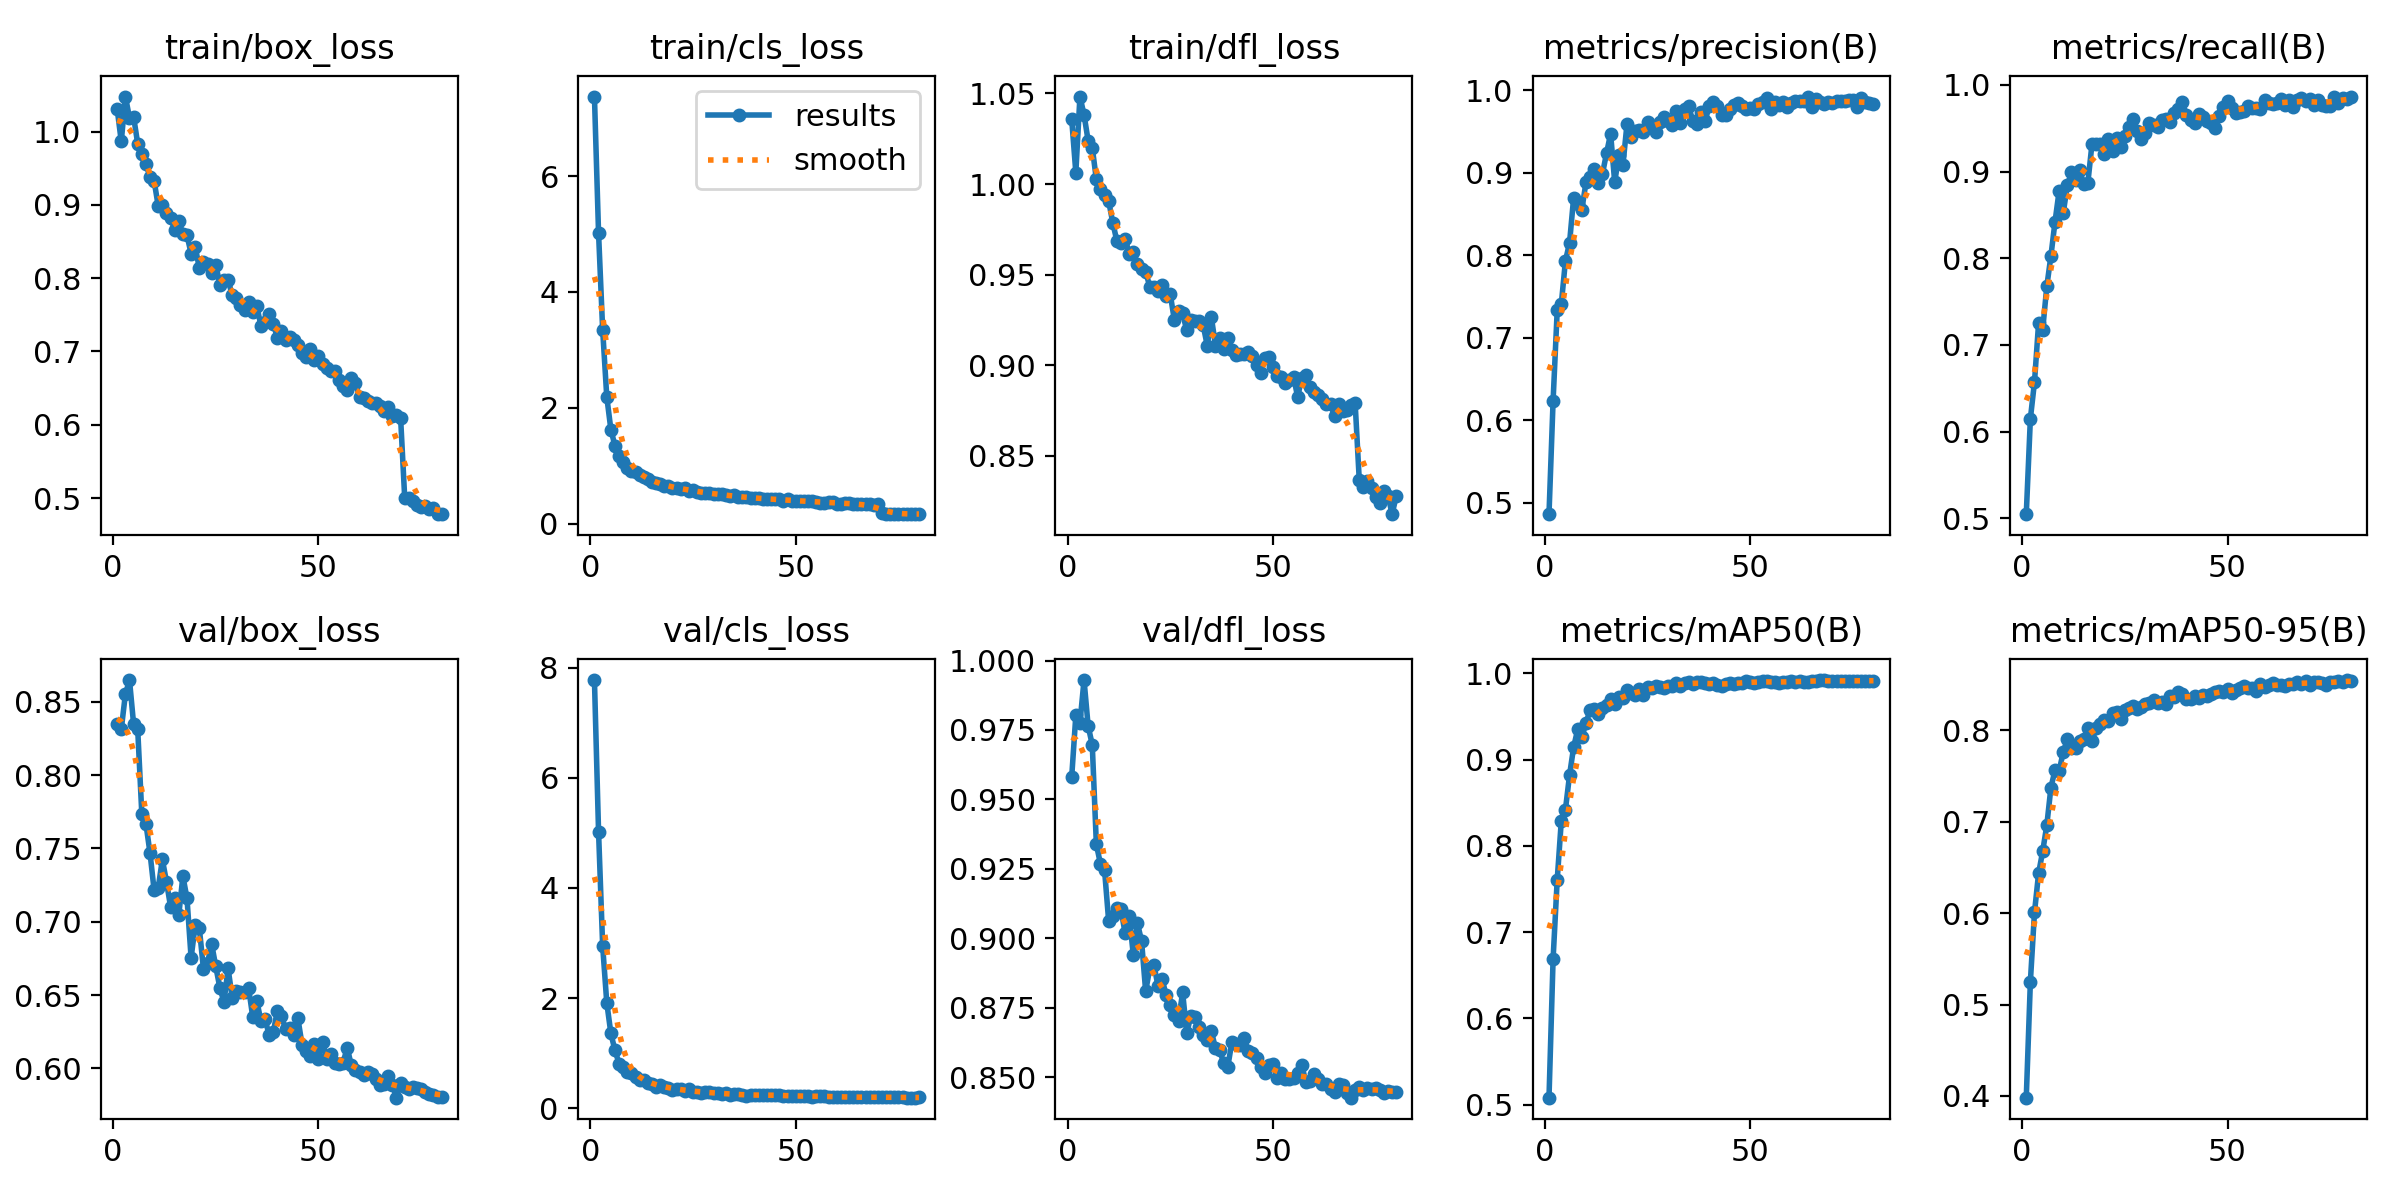

In [13]:
from IPython.display import Image as IPImage

# 학습 결과 그래프
IPImage(filename=f"{PROJECT_DIR}/{RUN_NAME}/results.png")

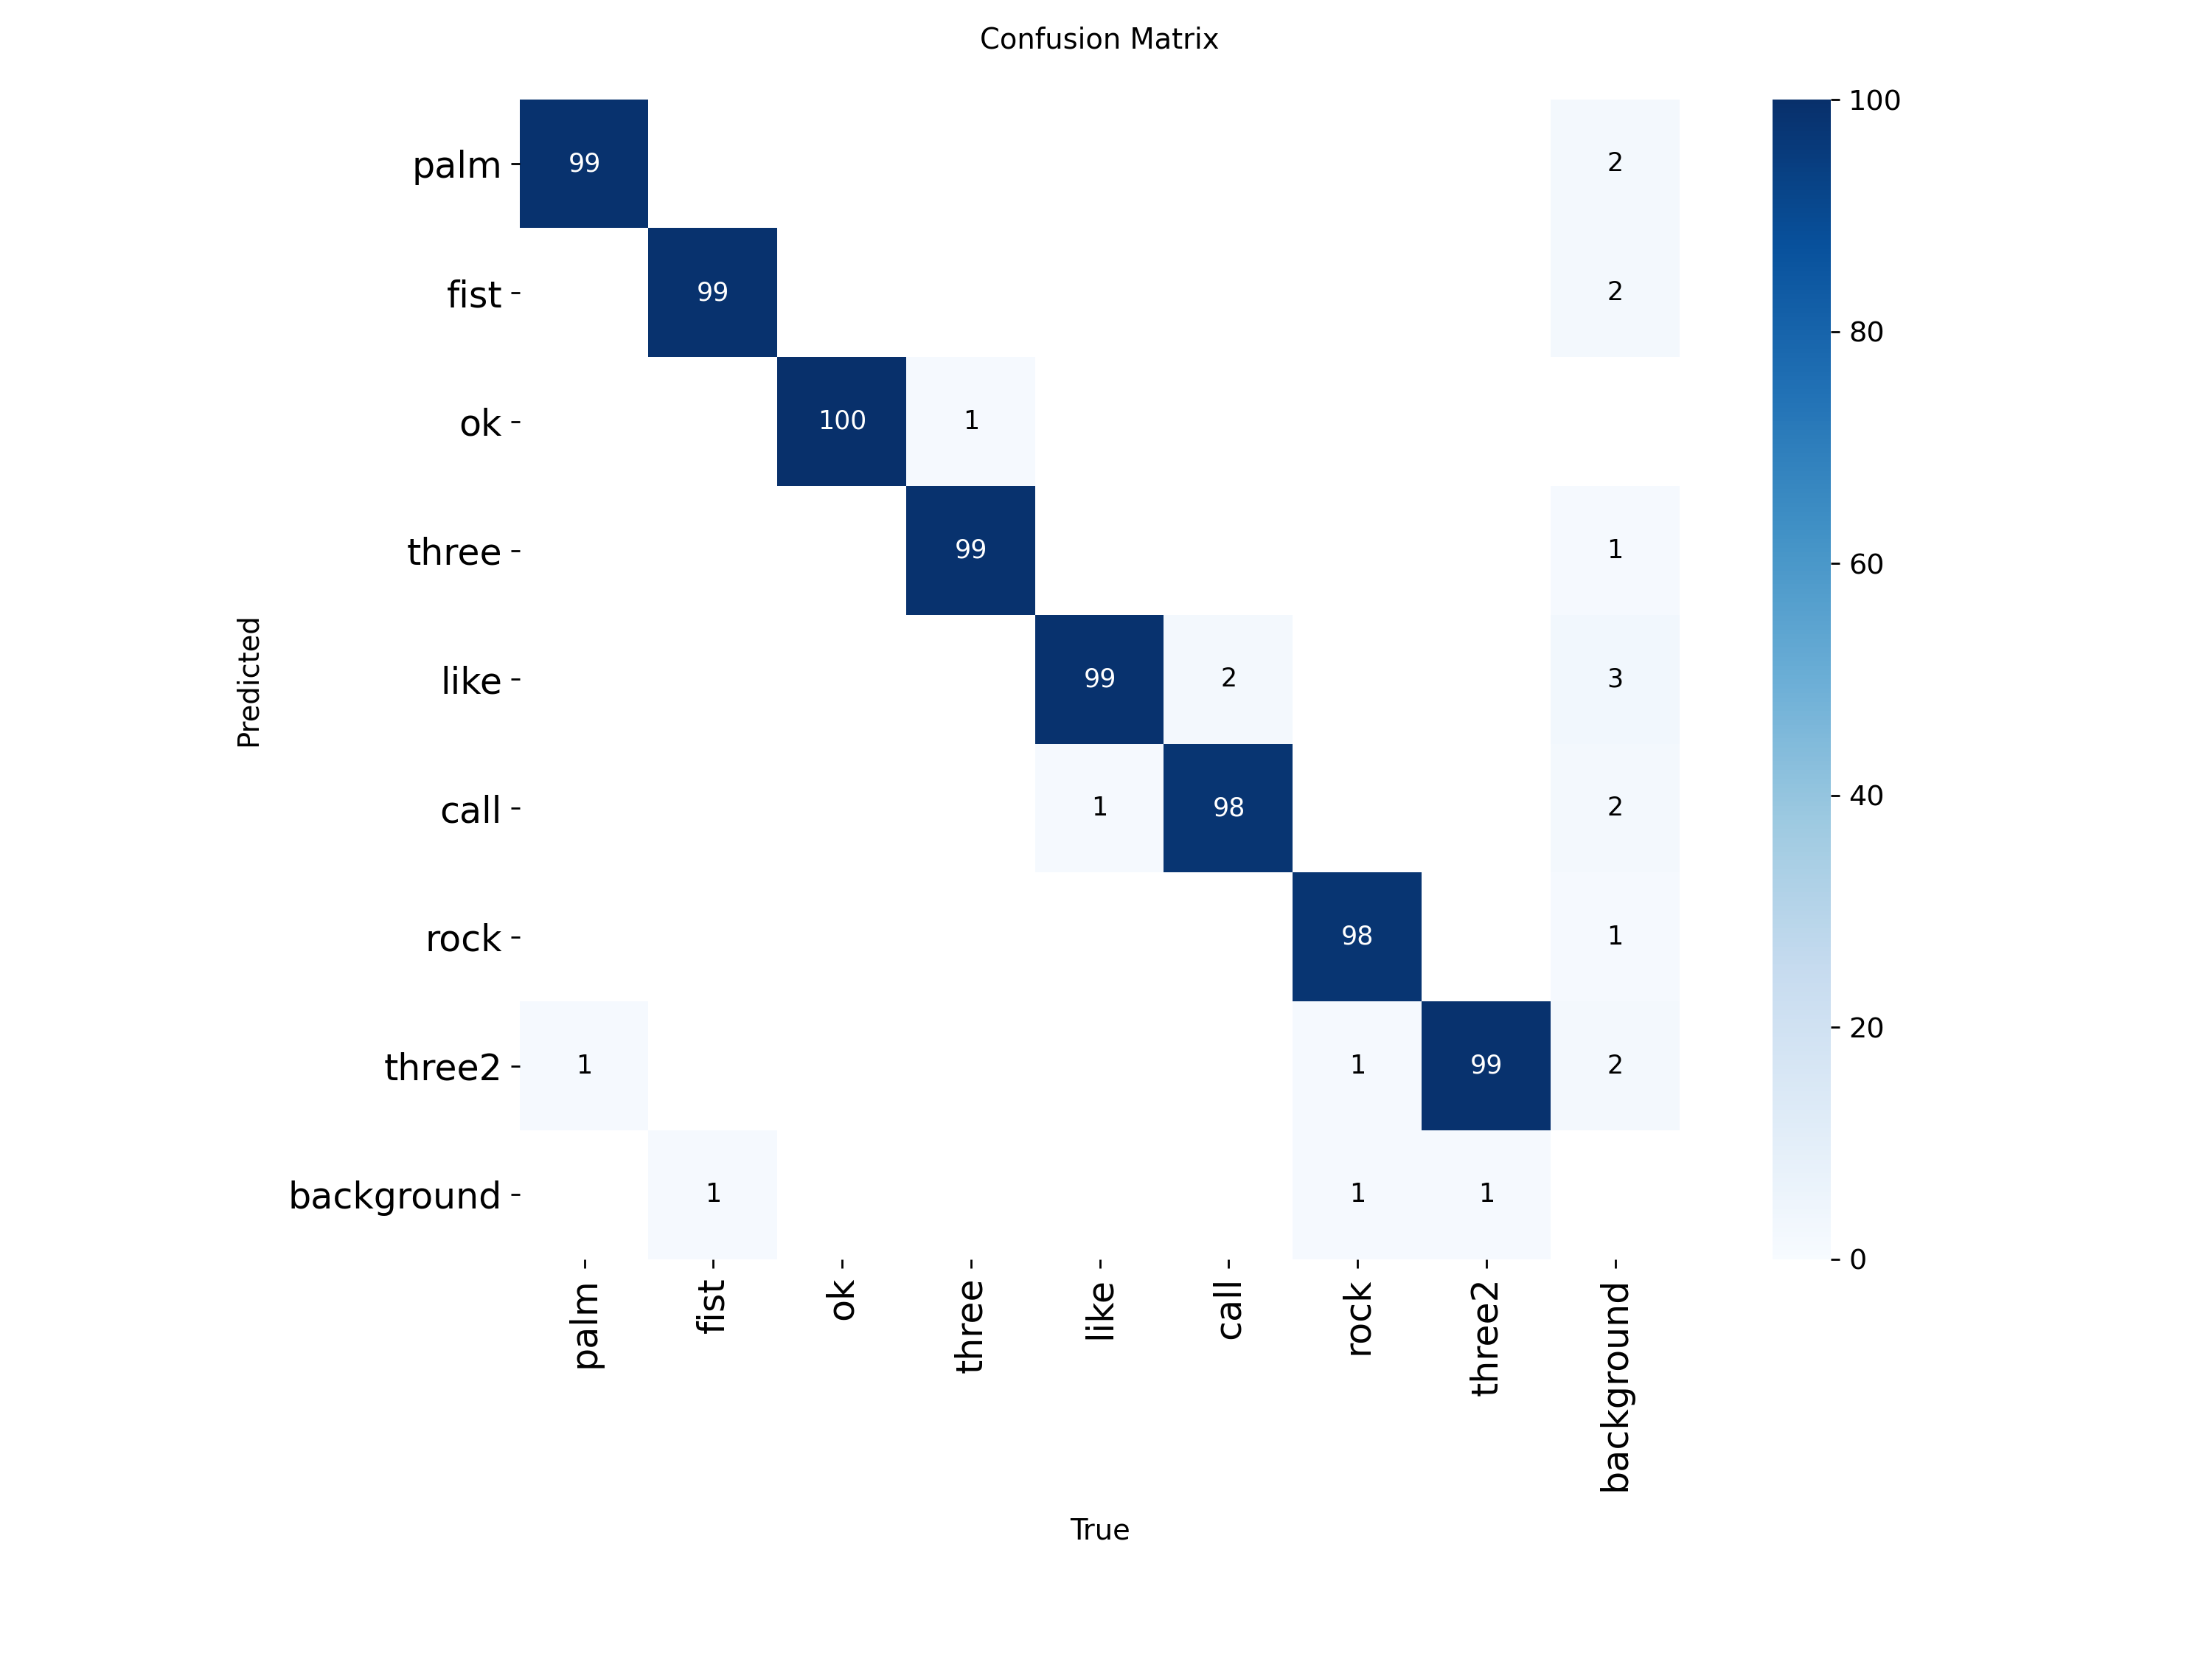

In [14]:
# confusion_matrix
IPImage(filename=f"{PROJECT_DIR}/{RUN_NAME}/confusion_matrix.png")

## 6. 검증셋 성능 평가

In [16]:
# ============================================================
# 노인 데이터셋 설정 (검증용)
# ============================================================
DRIVE_ELDERLY_ZIP = "/content/drive/MyDrive/HandSpark/OSSP-Labeling.coco.zip"
ELDERLY_RAW_DIR   = "/content/data/elderly_hand_yolo"
ELDERLY_CONV_DIR  = "/content/data/elderly_yolo_converted"

import os, json, shutil
from pathlib import Path

os.makedirs(ELDERLY_RAW_DIR, exist_ok=True)
!unzip -q "{DRIVE_ELDERLY_ZIP}" -d "{ELDERLY_RAW_DIR}"

# COCO → YOLO 변환
STAGE1_CLASSES = ["palm", "fist", "ok", "three", "like", "call", "rock", "three2"]
NAME_TO_ID = {name: i for i, name in enumerate(STAGE1_CLASSES)}

SRC = Path(ELDERLY_RAW_DIR)
DST = Path(ELDERLY_CONV_DIR)
SPLITS = {"train": "train", "valid": "val", "test": "test"}

for dst in SPLITS.values():
    (DST / "images" / dst).mkdir(parents=True, exist_ok=True)
    (DST / "labels" / dst).mkdir(parents=True, exist_ok=True)

for src_split, dst_split in SPLITS.items():
    json_path = SRC / src_split / "_annotations.coco.json"
    if not json_path.exists():
        continue
    with open(json_path) as f:
        coco = json.load(f)

    coco_to_yolo = {
        cat["id"]: NAME_TO_ID[cat["name"]]
        for cat in coco["categories"] if cat["name"] in NAME_TO_ID
    }
    img_info = {img["id"]: img for img in coco["images"]}
    anns_by_img = {}
    for ann in coco["annotations"]:
        anns_by_img.setdefault(ann["image_id"], []).append(ann)

    for img_id, info in img_info.items():
        fname = info["file_name"]
        W, H = info["width"], info["height"]
        src_img = SRC / src_split / fname
        if not src_img.exists():
            continue
        shutil.copy(src_img, DST / "images" / dst_split / fname)
        lines = []
        for ann in anns_by_img.get(img_id, []):
            yid = coco_to_yolo.get(ann["category_id"])
            if yid is None:
                continue
            x, y, w, h = ann["bbox"]
            cx, cy = (x + w/2)/W, (y + h/2)/H
            lines.append(f"{yid} {cx:.6f} {cy:.6f} {w/W:.6f} {h/H:.6f}")
        with open(DST / "labels" / dst_split / (Path(fname).stem + ".txt"), "w") as f:
            f.write("\n".join(lines))

# 노인 데이터용 yaml 생성
ELDERLY_DATASET_YAML = str(DST / "dataset.yaml")
Path(ELDERLY_DATASET_YAML).write_text(f"""path: {DST}
train: images/train
val: images/val
  test: images/test
  names:
    0: palm
    1: fist
    2: ok
    3: three
    4: like
    5: call
    6: rock
    7: three2
  """)
print("노인 데이터셋 준비 완료:", ELDERLY_DATASET_YAML)

노인 데이터셋 준비 완료: /content/data/elderly_yolo_converted/dataset.yaml


In [17]:
# 노인 데이터용 yaml 생성
ELDERLY_DATASET_YAML = str(DST / "dataset.yaml")
Path(ELDERLY_DATASET_YAML).write_text(f"""path: {DST}
train: images/train
val: images/val
test: images/test
names:
  0: palm
  1: fist
  2: ok
  3: three
  4: like
  5: call
  6: rock
  7: three2
""")
print("노인 데이터셋 준비 완료:", ELDERLY_DATASET_YAML)

노인 데이터셋 준비 완료: /content/data/elderly_yolo_converted/dataset.yaml


In [18]:
best_model = YOLO(f"{weights_dir}/best.pt")
metrics = best_model.val(data=ELDERLY_DATASET_YAML)

print("\n=== 검증 결과 ===")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10n summary (fused): 102 layers, 2,266,728 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1509.0±314.8 MB/s, size: 46.7 KB)
val: Scanning /content/data/elderly_yolo_converted/labels/val... 78 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 78/78 2.5Kit/s 0.0s
val: New cache created: /content/data/elderly_yolo_converted/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.2it/s 2.3s
                   all         78         81      0.398      0.458      0.429      0.268
                  palm         13         15      0.824      0.733      0.807      0.598
                  fist         12         12      0.368       0.63      0.527      0.303
                    ok          8          8      0.762       0.75      0.745      0.488
                 three          8          8     

## 7. 샘플 이미지로 추론 테스트


image 1/5 /content/data/elderly_yolo_converted/images/test/promise_012_jpg.rf.1bmDZUqrV5FplB8IhjMs.jpg: 640x640 (no detections), 11.3ms
image 2/5 /content/data/elderly_yolo_converted/images/test/gun_032_jpg.rf.AVRoIhM6k1P5wEVD4jfI.jpg: 640x640 (no detections), 10.8ms
image 3/5 /content/data/elderly_yolo_converted/images/test/promise_014_jpg.rf.zOgJpf55O3k2p3PR2GUp.jpg: 640x640 1 fist, 10.2ms
image 4/5 /content/data/elderly_yolo_converted/images/test/rock_025_jpg.rf.B61xKDLyaYaXlt74lKgG.jpg: 640x640 1 three2, 11.0ms
image 5/5 /content/data/elderly_yolo_converted/images/test/palm_007_jpg.rf.neBvpCUFQioGt0fJhEXb.jpg: 640x640 1 three2, 9.9ms
Speed: 2.8ms preprocess, 10.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


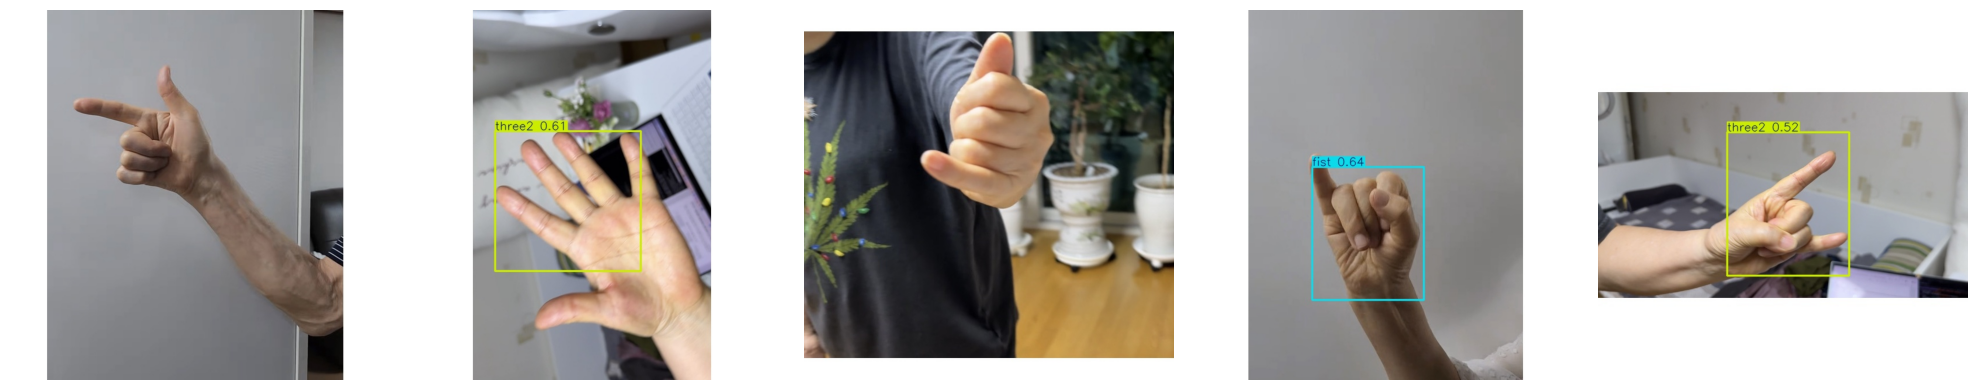

In [35]:
import glob, matplotlib.pyplot as plt, matplotlib.image as mpimg, os

# 노인 데이터셋 테스트 이미지 5장
elderly_test_images = glob.glob(f"{ELDERLY_CONV_DIR}/images/test/*.jpg")[:5]

if elderly_test_images:
    elderly_results = best_model.predict(elderly_test_images, save=True, conf=0.4)
    save_dir = elderly_results[0].save_dir

    saved_files = sorted(os.listdir(save_dir))[:5]
    fig, axes = plt.subplots(1, len(saved_files), figsize=(20, 4))
    for i, img_name in enumerate(saved_files):
        img = mpimg.imread(os.path.join(save_dir, img_name))
        axes[i].imshow(img)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("노인 테스트 이미지 없음. ELDERLY_CONV_DIR 경로 확인할 것.")

## 8. 가중치 Google Drive 백업

In [32]:
import shutil

DRIVE_SAVE_DIR = "/content/drive/MyDrive/HandSpark/weights"
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

shutil.copy(f"{weights_dir}/best.pt", f"{DRIVE_SAVE_DIR}/hagrid_stage1_8cls_best0622.pt")
print(f"저장됨: {DRIVE_SAVE_DIR}/hagrid_stage1_8cls_best0622.pt")

저장됨: /content/drive/MyDrive/HandSpark/weights/hagrid_stage1_8cls_best0622.pt
